# Cluster Sentences: blablabla

This notebook looks into techniques for defining clusters.
- First, sentences duplicates with a cosine similarity score of >=1 are removed.
- Compare resulting clusters of two lemmatisation methods (nltk, spacy, no lemma).

### Settings

In [1]:
# Settings
embedding_file = "embedding_corpus_free_3600_250606.pickle"
similarity_file = "similarity_corpus_free_3600_250606.pickle"

raw_corpus_file = "corpus_free_3600_250606.csv"
used_st_model = "NeuML/pubmedbert-base-embeddings"

# files for comparing lemmatisation methods
# Multiple vector files
folder = "explore_vectors"
filename1 = 'no_lemma_applied_df_xml2corpus_by_sentence_pmid_free_3600_250606.pickle'
filename2 = 'nltk_df_xml2corpus_by_sentence_pmid_free_3600_250606.pickle'
filename3 = 'spacy_df_xml2corpus_by_sentence_pmid_free_3600_250606.pickle'

## Initialisation

### Import and functions

In [2]:
# import
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
from sentence_transformers import SentenceTransformer

### Functions

In [ ]:
def get_duplets_dataframe(similarity_matrix, threshold: float = 1.0):
    """Return a similarity dataframe that only contains duplets, where duplets are defined as sentences with a similarity score equal or higher than provided threshold."""
    # Substract 2 from the cosine similarity score that matched itself, so that it turns the value to -1.
    df_duplets = pd.DataFrame(
        np.subtract(
            similarity_matrix, 
            np.identity(similarity_matrix.shape[0]) *2
        )
    )

    # Drop columns and rows without duplets (defined by the threshold)
    df_duplets = df_duplets[df_duplets >= threshold].dropna(axis=0, how='all')
    df_duplets = df_duplets[df_duplets >= threshold].dropna(axis=1, how='all')

    return df_duplets

### Load

In [3]:
# Load raw corpus
df_corpus = pd.read_csv(f'../../data/corpus/{raw_corpus_file}')

# Load cosine similarity scores
with open(f"../../data/vectors/{similarity_file}", 'rb') as handle:
    similarities = pickle.load(handle)

# Load sentence embeddings
with open(f"../../data/vectors/{embedding_file}", 'rb') as handle:
    embeddings = pickle.load(handle)


In [ ]:
# sample
similarities[:5, :5]

tensor([[1.0000, 0.1074, 0.2322, 0.5048, 0.3413],
        [0.1074, 1.0000, 0.4907, 0.3195, 0.5344],
        [0.2322, 0.4907, 1.0000, 0.3907, 0.4358],
        [0.5048, 0.3195, 0.3907, 1.0000, 0.3484],
        [0.3413, 0.5344, 0.4358, 0.3484, 1.0000]])

Similarity scores are correctly loaded if row and column indices with the same number == `1`

In [5]:
embeddings.shape

(18305, 768)

In [6]:
similarities.shape

torch.Size([18305, 18305])

## Remove duplets (So that one unique remains)

As noted in notebook `sentence_pairs.ipynb`, there are multiple duplicated sentences. 
For clustering I would like to remove these duplicates, since we are interested in sentence similarities, I think that the 'high similarity' duplicate sentences have may influence the formation of clusters.

/homes/jbeenen/venv/graduation/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/homes/jbeenen/venv/graduation/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


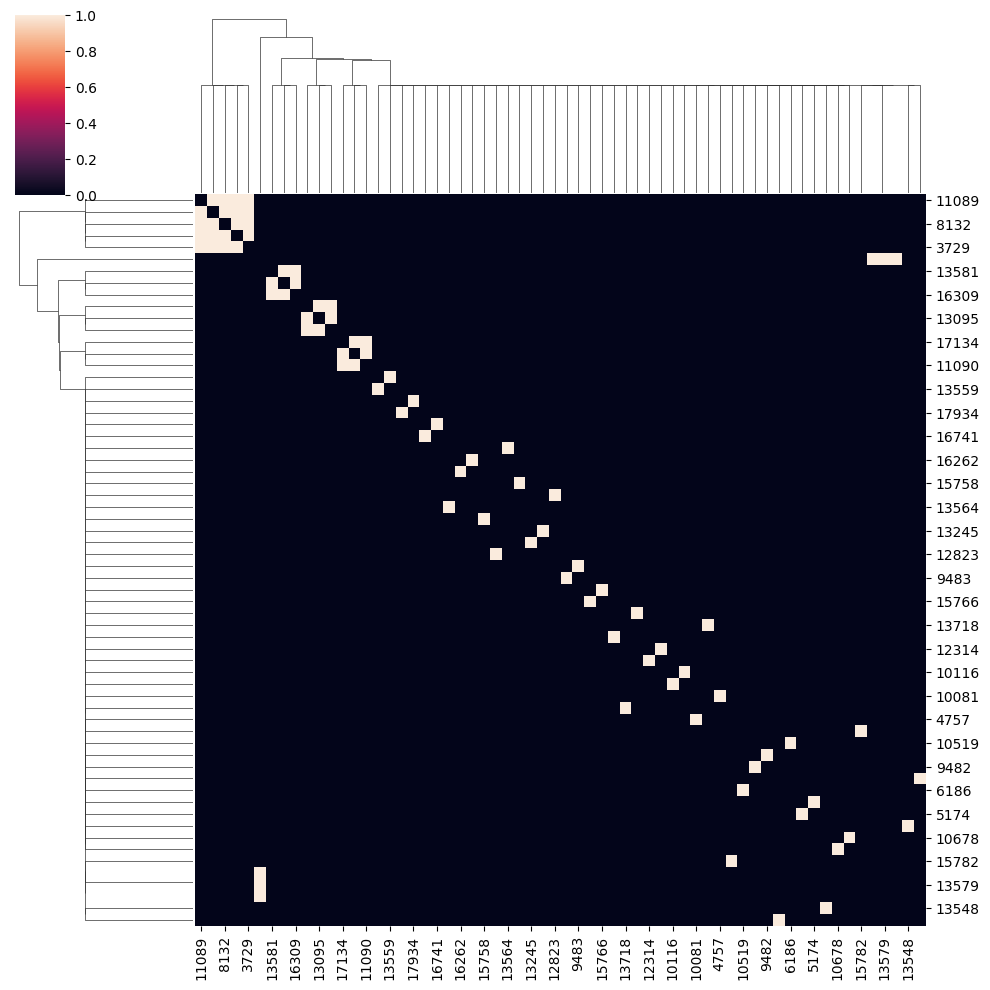

In [11]:
# Visualize clusters of duplets
sns.clustermap(get_duplets_dataframe(similarities).fillna(0))

In [11]:
# First occurrence is saved. The rest will be removed. (This will automatically shorten the list)
# I cannot think of a reason why it would matter which sentence would be removed.

# Create a list with indexes on sentences with a duplet.
# Iterate over list, 
    # for idx in list, find other idx that have same sentence.
    # (Store 'unique' idx in list_unique, and store 'duplets' idx in list_duplets)
    # drop duplets from `embeddings` and `similarity`
    # write a .csv with removed duplets and the sentence they contained. (This is important, because if the 'duplet' is a hit, we need to find it back in the corpus. Also if the hit occurs multiple times in the corpus.)

In [77]:
embeddings

array([[-0.5974111 , -0.07016714,  0.07821506, ...,  0.0422182 ,
        -0.32414603,  0.1534939 ],
       [-0.4023493 ,  0.05102281,  0.7707427 , ...,  0.40188006,
        -0.27104494,  0.9361009 ],
       [-0.28069857, -0.34555617,  0.6116313 , ...,  0.7380857 ,
        -0.94036996,  0.02352079],
       ...,
       [-0.49367264, -0.47659913, -0.047718  , ...,  0.57986104,
         0.64620817,  0.05219558],
       [-0.10325798, -0.46009225,  0.58131886, ...,  0.71023536,
         0.46549538,  0.7141325 ],
       [-0.11103514, -0.48243994,  0.80316913, ...,  0.35782537,
         0.60177493,  0.5823116 ]], dtype=float32)

In [ ]:
get

## Test

In [ ]:
def get_duplets_clusters(df_duplets):
    """Return a dictionary where the kept 'unique sentence index' (=key) references to the duplet indice in a list (=values)."""
    # Create a list with indexes on sentences with a duplet.
    potential_duplets = df_duplets.index
    # duplet_to_remove = list()
    duplet_dict = dict()

    # Iterate over list, 
    # TODO: There should be a nicer way with groupby or something
    while len(potential_duplets) != 0:
        # look at first item
        idx = potential_duplets[0]
        # print("\n-------\n")
        # print(idx)
        # for idx in list, find other idx that have same sentence.
        cluster = df_duplets.loc[idx, ~df_duplets.loc[idx].isna()].index
        if len(cluster) >= 1: # TODO: there should be a nicer way..
            # (Store 'unique' idx in unique_list, and store 'duplet' idx in duplet_list)
            # duplet_to_remove.extend(cluster.to_list())
            # print(f"duplet_to_remove: {duplet_to_remove}")

            duplet_dict[idx] = cluster.to_list()
            # print(f"duplet_dict: {duplet_dict}")

            # remove duplet indice and first item from potential_duplets
            potential_duplets = potential_duplets[~potential_duplets.isin(cluster)]
            potential_duplets = potential_duplets[1:]
            # print(f"potential_duplets {potential_duplets}")

    return duplet_dict

In [14]:
duplet_to_remove, duplet_dict = get_duplets_clusters(
    get_duplets_dataframe(
        similarities
    )
)

In [23]:
np.array(duplet_dict.values()).flatten()

array([dict_values([[3729, 8132, 9212, 11089], [11090, 17134], [5174], [10081], [10519], [13720], [13718], [9489], [9490], [13579, 15557, 15795], [10116], [10742], [12314], [15384], [16227, 17936], [13245], [15754], [15758], [13548], [15787], [16299], [15797, 16309], [16251], [16262], [16285], [16744], [18298]])],
      dtype=object)

In [31]:
duplet_to_remove == [item for layer in duplet_dict.values() for item in layer]

True

In [14]:
# First occurrence is saved. The rest will be removed. (This will automatically shorten the list)
# I cannot think of a reason why it would matter which sentence would be removed.

# Create a list with indexes on sentences with a duplet.
potential_duplets = df_duplets.index
duplet_to_remove = list()
duplet_dict = dict()

# Iterate over list, 
# TODO: There should be a nicer way with groupby or something
while len(potential_duplets) != 0:
    # look at first item
    idx = potential_duplets[0]
    # print("\n-------\n")
    # print(idx)
    # for idx in list, find other idx that have same sentence.
    cluster = df_duplets.loc[idx, ~df_duplets.loc[idx].isna()].index
    if len(cluster) >= 1: # TODO: there should be a nicer way..
        # (Store 'unique' idx in unique_list, and store 'duplet' idx in duplet_list)
        duplet_to_remove.extend(cluster.to_list())
        # print(f"duplet_to_remove: {duplet_to_remove}")

        duplet_dict[idx] = cluster.to_list()
        # print(f"duplet_dict: {duplet_dict}")

        # remove duplet indice and first item from potential_duplets
        potential_duplets = potential_duplets[~potential_duplets.isin(cluster)]
        potential_duplets = potential_duplets[1:]
        # print(f"potential_duplets {potential_duplets}")

# TODO:TODO:TODO:TODO:TODO:TODO:TODO:TODO:TODO:TODO:TODO:TODO:
# embeddings.drop(cluster, axis= 0, inplace= True)
# print(f"embedding shape: {embeddings.shape}")
embeddings = np.delete(embeddings, duplet_to_remove, 0)
# print(f"embedding shape: {embeddings.shape}")

# TODO: there is probably an elegant way with torch, 
# but after a lot of time I did not manage to figure it out...
# print(f"similarities shape: {similarities.shape}")
similarities = pd.DataFrame(similarities).drop(duplet_to_remove, axis= 0)
similarities = similarities.drop(duplet_to_remove, axis= 1)
# print(f"similarities shape: {similarities.shape}")


print(f"duplet_dict: {duplet_dict}")
print(f"duplet_to_remove: {duplet_to_remove}")
print(f"potential_duplets {potential_duplets}")

duplet_dict: {0: [1], 474: [3729, 8132, 9212, 11089], 475: [11090, 17134], 3955: [5174], 4757: [10081], 6186: [10519], 8718: [13720], 9140: [13718], 9482: [9489], 9483: [9490], 9513: [13579, 15557, 15795], 10090: [10116], 10678: [10742], 12312: [12314], 12823: [15384], 13095: [16227, 17936], 13238: [13245], 13534: [15754], 13539: [15758], 13541: [13548], 13559: [15787], 13564: [16299], 13581: [15797, 16309], 15766: [16251], 15773: [16262], 15782: [16285], 16741: [16744], 17934: [18298]}
duplet_to_remove: [1, 3729, 8132, 9212, 11089, 11090, 17134, 5174, 10081, 10519, 13720, 13718, 9489, 9490, 13579, 15557, 15795, 10116, 10742, 12314, 15384, 16227, 17936, 13245, 15754, 15758, 13548, 15787, 16299, 15797, 16309, 16251, 16262, 16285, 16744, 18298]
potential_duplets Index([], dtype='int64')


In [12]:
duplet_dict

NameError: name 'duplet_dict' is not defined

## Check if duplets are removed

In [15]:
# Substract 2 from the cosine similarity score that matched itself, so that it turns the value to -1.
retrieve_sim_sent = np.subtract(similarities, np.identity(similarities.shape[0]) *2)

df_test = pd.DataFrame(retrieve_sim_sent)

In [17]:
df_test.iloc[:5, :5]

,0,2,3,4,5
0,-1.000000,0.232179,0.504831,0.341290,0.676102
2,0.232179,-1.000000,0.390672,0.435770,0.306392
3,0.504831,0.390672,-1.000000,0.348351,0.315000
4,0.341290,0.435770,0.348351,-1.000000,0.499264
5,0.676102,0.306392,0.315000,0.499264,-1.000000


In [ ]:
# Visualize clusters of duplets
sns.clustermap(df_test.fillna(0))

/homes/jbeenen/venv/graduation/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


In [ ]:
# # First occurrence is saved. The rest will be removed. (This will automatically shorten the list)
# # I cannot think of a reason why it would matter which sentence would be removed.

# # Create a list with indexes on sentences with a duplet.
# potential_duplets = df_duplets.index
# duplet_to_remove = list()
# duplet_dict = dict()

# # Iterate over list, 
# # TODO: There should be a nicer way with groupby or something
# for idx in potential_duplets:
#     print("\n-------\n")
#     print(idx)
#     # for idx in list, find other idx that have same sentence.
#     cluster = df_duplets.loc[idx, ~df_duplets.loc[idx].isna()].index
#     if len(cluster) >= 1: # TODO: there should be a nicer way..
#         # (Store 'unique' idx in unique_list, and store 'duplet' idx in duplet_list)
#         duplet_to_remove.append(cluster)
#         print(f"duplet_to_remove: {duplet_to_remove}")

#         duplet_dict[idx] = cluster.to_list()
#         print(f"duplet_dict: {duplet_dict}")

#         # drop duplets from `embeddings` and `similarities`
#             # for `embeddings` only the row needs to be dropped,
#             # for `similarities` both rows and columns

#         # remove duplet indice from potential_duplets
#         potential_duplets = potential_duplets[~potential_duplets.isin(cluster)]
#         print(f"potential_duplets {potential_duplets}")
        

#         # write a .csv with removed duplets and the sentence they contained. (This is important, because if the 'duplet' is a hit, we need to find it back in the corpus. Also if the hit occurs multiple times in the corpus.)
#     else:
#         print(f"Something special happened with {idx}")


# # # embeddings.drop(cluster, axis= 0, inplace= True)
# # embeddings = np.delete(embeddings, duplet_to_remove, 0)

# # # TODO: there is probably an elegant way with torch, 
# # # but after a lot of time I did not manage to figure it out...
# # similarities = pd.DataFrame(similarities).drop(duplet_to_remove, axis= 0)
# # similarities = similarities.drop(duplet_to_remove, axis= 1)


# # similarities.drop(duplet_list, axis= 0, inplace= True)
# # similarities.drop(duplet_list, axis= 1, inplace= True)


# print(f"Unique_list: {duplet_dict}")
# print(f"Unique_list: {duplet_to_remove}")
# print(f"Unique_list: {potential_duplets}")


-------

0
duplet_to_remove: [Index([1], dtype='int64')]
duplet_dict: {0: [1]}
potential_duplets Index([    0,   474,   475,  3729,  3955,  4757,  5174,  6186,  8132,  8718,
        9140,  9212,  9482,  9483,  9489,  9490,  9513, 10081, 10090, 10116,
       10519, 10678, 10742, 11089, 11090, 12312, 12314, 12823, 13095, 13238,
       13245, 13534, 13539, 13541, 13548, 13559, 13564, 13579, 13581, 13718,
       13720, 15384, 15557, 15754, 15758, 15766, 15773, 15782, 15787, 15795,
       15797, 16227, 16251, 16262, 16285, 16299, 16309, 16741, 16744, 17134,
       17934, 17936, 18298],
      dtype='int64')

-------

1
duplet_to_remove: [Index([1], dtype='int64'), Index([0], dtype='int64')]
duplet_dict: {0: [1], 1: [0]}
potential_duplets Index([  474,   475,  3729,  3955,  4757,  5174,  6186,  8132,  8718,  9140,
        9212,  9482,  9483,  9489,  9490,  9513, 10081, 10090, 10116, 10519,
       10678, 10742, 11089, 11090, 12312, 12314, 12823, 13095, 13238, 13245,
       13534, 13539, 13541

In [185]:
potential_duplets.shape

(0,)

In [184]:
len(duplet_dict)

64

In [156]:
[*duplet_to_remove][0]

Index([1], dtype='int64')

In [ ]:
similarities.

Index([474, 3729, 8132, 9212], dtype='int64')

In [125]:
similarities[cluster]

tensor([[-0.0457,  0.1461, -0.0099,  ...,  0.0874,  0.0731,  0.0822],
        [-0.0457,  0.1461, -0.0099,  ...,  0.0874,  0.0731,  0.0822],
        [-0.0457,  0.1461, -0.0099,  ...,  0.0874,  0.0731,  0.0822],
        [-0.0457,  0.1461, -0.0099,  ...,  0.0874,  0.0731,  0.0822]])

In [ ]:
import torch

torch.BoolTensor()

# torch.masked_select(similarities, ~cluster)

TypeError: masked_select(): argument 'mask' (position 2) must be Tensor, not Index

In [133]:
type(similarities)

torch.Tensor

In [134]:
similarities.index

AttributeError: 'Tensor' object has no attribute 'index'

In [139]:
pd.DataFrame(similarities).drop(cluster, axis= 0).shape
pd.DataFrame(similarities).drop(cluster, axis= 1).shape

(18305, 18301)

In [95]:
type(similarities)

torch.Tensor

In [98]:
cluster

Index([17934], dtype='int64')

In [104]:
embeddings[cluster]

array([[-0.40355802,  0.11817827,  0.30357152, ...,  0.5240142 ,
        -0.7174028 ,  0.32203254],
       [-0.40355802,  0.11817827,  0.30357152, ...,  0.5240142 ,
        -0.7174028 ,  0.32203254],
       [-0.40355802,  0.11817827,  0.30357152, ...,  0.5240142 ,
        -0.7174028 ,  0.32203254],
       [-0.40355802,  0.11817827,  0.30357152, ...,  0.5240142 ,
        -0.7174028 ,  0.32203254]], dtype=float32)

In [82]:
arr = np.array([[1,2,3,4], [5,6,7,8], [9,10,11,12]])
arr

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [85]:
np.delete(arr, 0,0)

array([[ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [88]:
embeddings.shape

(18305, 768)

In [90]:
cluster

Index([1], dtype='int64')

In [92]:
np.delete(embeddings, cluster, 0).shape

(18301, 768)

In [87]:
np.delete(embeddings, 0, 0).shape

(18304, 768)

In [ ]:
# per row (11089), select columns that are not na, and gather the indices
df_duplets.loc[11089, ~df_duplets.loc[11089].isna()].index

Index([474, 3729, 8132, 9212], dtype='int64')

In [70]:
potential_duplets = df_duplets.index
potential_duplets

Index([    0,     1,   474,   475,  3729,  3955,  4757,  5174,  6186,  8132,
        8718,  9140,  9212,  9482,  9483,  9489,  9490,  9513, 10081, 10090,
       10116, 10519, 10678, 10742, 11089, 11090, 12312, 12314, 12823, 13095,
       13238, 13245, 13534, 13539, 13541, 13548, 13559, 13564, 13579, 13581,
       13718, 13720, 15384, 15557, 15754, 15758, 15766, 15773, 15782, 15787,
       15795, 15797, 16227, 16251, 16262, 16285, 16299, 16309, 16741, 16744,
       17134, 17934, 17936, 18298],
      dtype='int64')

In [67]:
for sent_id in cluster:
    print(sent_id)
    potential_duplets = potential_duplets.to_list().remove(sent_id)

potential_duplets

474
3729


AttributeError: 'NoneType' object has no attribute 'to_list'

In [99]:
idx =11089
cluster = df_duplets.loc[idx, ~df_duplets.loc[idx].isna()].index
cluster

Index([474, 3729, 8132, 9212], dtype='int64')

In [59]:
type(potential_duplets)

pandas.core.indexes.base.Index

In [73]:
potential_duplets

Index([    0,     1,   474,   475,  3729,  3955,  4757,  5174,  6186,  8132,
        8718,  9140,  9212,  9482,  9483,  9489,  9490,  9513, 10081, 10090,
       10116, 10519, 10678, 10742, 11089, 11090, 12312, 12314, 12823, 13095,
       13238, 13245, 13534, 13539, 13541, 13548, 13559, 13564, 13579, 13581,
       13718, 13720, 15384, 15557, 15754, 15758, 15766, 15773, 15782, 15787,
       15795, 15797, 16227, 16251, 16262, 16285, 16299, 16309, 16741, 16744,
       17134, 17934, 17936, 18298],
      dtype='int64')

In [ ]:
sorter[np.searchsorted(a, values, sorter=sorter)] 

In [72]:
potential_duplets[~potential_duplets.isin(cluster)]

Index([    0,     1,   475,  3955,  4757,  5174,  6186,  8718,  9140,  9482,
        9483,  9489,  9490,  9513, 10081, 10090, 10116, 10519, 10678, 10742,
       11089, 11090, 12312, 12314, 12823, 13095, 13238, 13245, 13534, 13539,
       13541, 13548, 13559, 13564, 13579, 13581, 13718, 13720, 15384, 15557,
       15754, 15758, 15766, 15773, 15782, 15787, 15795, 15797, 16227, 16251,
       16262, 16285, 16299, 16309, 16741, 16744, 17134, 17934, 17936, 18298],
      dtype='int64')

In [55]:
np.delete(potential_duplets.to_numpy(), potential_duplets.isin(cluster))


array([    0,     1,   475,  3955,  4757,  5174,  6186,  8718,  9140,
        9482,  9483,  9489,  9490,  9513, 10081, 10090, 10116, 10519,
       10678, 10742, 11089, 11090, 12312, 12314, 12823, 13095, 13238,
       13245, 13534, 13539, 13541, 13548, 13559, 13564, 13579, 13581,
       13718, 13720, 15384, 15557, 15754, 15758, 15766, 15773, 15782,
       15787, 15795, 15797, 16227, 16251, 16262, 16285, 16299, 16309,
       16741, 16744, 17134, 17934, 17936, 18298])

In [38]:
# numpy way
# https://stackoverflow.com/questions/23979146/check-if-numpy-array-is-in-list-of-numpy-arrays
np.any(np.all(potential_duplets == cluster, axis= 1))

ValueError: Lengths must match to compare